# Logistic Regression and Evaluation — Solution

**Dataset:** Swiss avalanche accident records; fatal = 1 if at least one person died.

Run from top to bottom. The steps match the exercise; short answers explain the results.

## Libraries and settings

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score, accuracy_score
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
from sklearn.metrics import precision_score, recall_score, f1_score, roc_auc_score, RocCurveDisplay

## 1. Calculate a probability

For score 1, replace the gap with `1 / (1 + np.exp(-score))`. Which label follows at threshold 0.5?

In [2]:
score = 1
p = 1 / (1 + np.exp(-score))
print('Probability:', round(p, 3))
print('Class at threshold 0.5:', int(p >= 0.5))

Probability: 0.731
Class at threshold 0.5: 1


**Answer:** The probability is 0.731, so the predicted class is 1.

- For score 1: e^(−1) ≈ 0.368.
- p = 1 / (1 + 0.368) = 1 / 1.368 ≈ 0.731.
- 0.731 is at least 0.5, so the label is 1.

## 2. Load and split accident records

Preparation is provided. How is a positive case defined? At what time is the input available?

In [3]:
aval = pd.read_csv('../00_Data/avalanche_accidents_switzerland.csv')
aval = aval[aval['hydrological_year'] >= '2000/01'].copy()
aval = aval.dropna(subset=['fully_buried', 'fatal'])
X = aval[['fully_buried']]
y = aval['fatal']
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42)
print('Accidents:', len(aval), 'Share fatal:', round(y.mean(), 3))
print(X_train.head())

Accidents: 2876 Share fatal: 0.132
      fully_buried
2203           0.0
2338           0.0
1636           0.0
3625           0.0
2566           0.0


**Answer:** A positive case (`fatal = 1`) is an accident with at least one death.

- The data contain 2876 recorded accidents since 2000/01; 13.2% of them were fatal.
- With `stratify=y`, training (2300 accidents) and test (576 accidents) both keep this 13.2% share. The test set contains 76 fatal accidents.
- The number of fully buried people is only known after an accident has happened.
- This is therefore a teaching model for outcomes of recorded accidents, not a pre-trip avalanche forecast.

## 3. Train and see the sigmoid

Replace the gap with `LogisticRegression()`. Does more burial correspond to higher predicted probability?

Intercept: [-3.0961586] Slope: [[2.25669197]]


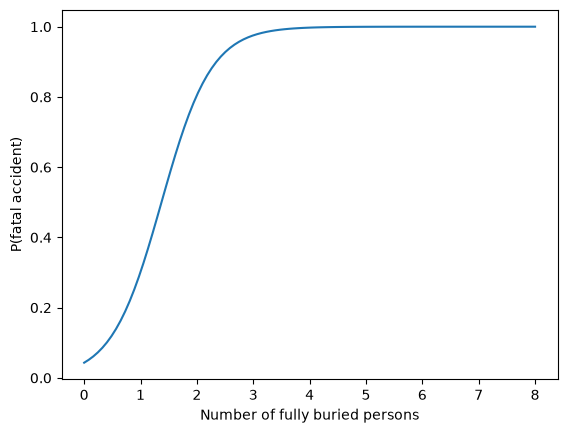

In [4]:
model = LogisticRegression()
model.fit(X_train, y_train)
print('Intercept:', model.intercept_, 'Slope:', model.coef_)
grid = pd.DataFrame({'fully_buried': np.linspace(0, 8, 100)})
plt.plot(grid['fully_buried'], model.predict_proba(grid)[:, 1])
plt.xlabel('Number of fully buried persons')
plt.ylabel('P(fatal accident)')
plt.show()
probability = model.predict_proba(X_test)[:, 1]

**Answer:** Yes. The slope is positive (2.26), so the curve rises with the number of fully buried people.

- Intercept −3.10: with nobody fully buried, p = 1 / (1 + e^3.10) ≈ 0.043.
- Each extra fully buried person adds 2.26 to the score. This multiplies the odds of a fatal outcome by e^2.26 ≈ 9.6.
- Predicted probabilities: 0 buried → 0.043; 1 buried → 0.302; 2 buried → 0.805; 3 buried → 0.975.
- The curve rises steeply between 1 and 2 buried people and flattens near 1 from 3 upwards.
- This is an association within the recorded accidents, not a causal effect.

## 4. Compute precision and recall by hand

Use the counts TN=75, FP=22, FN=24, TP=50. Replace the gap with `TP / (TP + FN)`. Explain precision versus recall.

In [5]:
TN, FP, FN, TP = 75, 22, 24, 50
precision = TP / (TP + FP)
recall = TP / (TP + FN)
print('Precision:', round(precision, 3))
print('Recall:', round(recall, 3))
print('FPR:', round(FP / (FP + TN), 3))

Precision: 0.694
Recall: 0.676
FPR: 0.227


**Answer:** Precision = 0.694 and recall = 0.676.

- **Precision** = 50 / (50 + 22) = 50 / 72 ≈ 0.694. Of the 72 cases predicted positive, 50 are actually positive. When the model raises an alarm, it is right about 69% of the time.
- **Recall** = 50 / (50 + 24) = 50 / 74 ≈ 0.676. Of the 74 actual positives, 50 are found. The model finds about 68% of the positives and misses 24.
- **FPR** = 22 / (22 + 75) = 22 / 97 ≈ 0.227. About 23% of the actual negatives are falsely flagged.
- Precision looks at the predicted positives; recall looks at the actual positives.

## 5. Evaluate the model

The evaluation is provided. Read the matrix rows and columns, and compare accuracy with the always-negative baseline. Why is recall also needed?

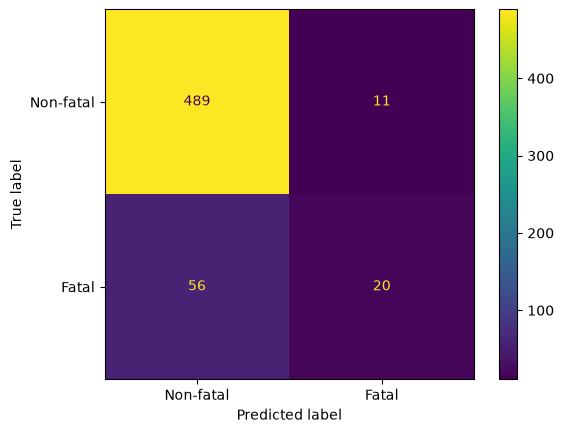

Accuracy: 0.884
Precision: 0.645
Recall: 0.263
F1: 0.374
Always-negative accuracy: 0.868


In [6]:
predicted = (probability >= 0.5).astype(int)
cm = confusion_matrix(y_test, predicted, labels=[0, 1])
ConfusionMatrixDisplay(cm, display_labels=['Non-fatal', 'Fatal']).plot()
plt.show()
print('Accuracy:', round(accuracy_score(y_test, predicted), 3))
print('Precision:', round(precision_score(y_test, predicted, zero_division=0), 3))
print('Recall:', round(recall_score(y_test, predicted), 3))
print('F1:', round(f1_score(y_test, predicted), 3))
print('Always-negative accuracy:', round(1 - y_test.mean(), 3))

**Answer:** Rows show the actual outcome, columns the predicted outcome.

- At threshold 0.5, the test matrix is: TN = 489, FP = 11, FN = 56, TP = 20.
- Because p(1 buried) = 0.302 and p(2 buried) = 0.805, threshold 0.5 means: predict fatal if 2 or more people are fully buried.
- **Accuracy** = (489 + 20) / 576 = 0.884.
- **Always-negative baseline:** predicting "non-fatal" for every accident is right for the 500 non-fatal cases: 500 / 576 = 0.868. The model is only 0.016 better.
- **Precision** = 20 / 31 = 0.645: about two thirds of the fatal alarms are correct.
- **Recall** = 20 / 76 = 0.263: only about one in four fatal accidents is found. 43 of the 56 missed cases had exactly one fully buried person.
- **F1** = 0.374, low because recall is low.
- Accuracy hides these misses, because 87% of the accidents are non-fatal anyway. Recall shows how many fatal cases the model actually identifies; the always-negative baseline has recall 0.

## 6. Compare two fixed thresholds

This comparison is supplied. What changes when the threshold goes from 0.5 to 0.3? Costs of 10 per missed positive and 1 per false alarm are illustrative. Do not choose a new threshold from this test comparison.

In [7]:
for threshold in [0.5, 0.3]:
    labels = (probability >= threshold).astype(int)
    TN, FP, FN, TP = confusion_matrix(y_test, labels, labels=[0, 1]).ravel()
    print('Threshold:', threshold, 'FP:', FP, 'FN:', FN,
          'recall:', round(TP / (TP + FN), 3),
          'illustrative cost:', 10 * FN + FP)

Threshold: 0.5 FP: 11 FN: 56 recall: 0.263 illustrative cost: 571
Threshold: 0.3 FP: 88 FN: 13 recall: 0.829 illustrative cost: 218


**Answer:** Lowering the threshold from 0.5 to 0.3 finds many more fatal accidents but raises many more false alarms.

- p(1 buried) = 0.302 is above 0.3, so the rule becomes: predict fatal if 1 or more people are fully buried.
- **Missed fatal accidents (FN):** fall from 56 to 13.
- **Recall:** rises from 0.263 to 0.829 (63 of 76 found).
- **False alarms (FP):** rise from 11 to 88.
- **Illustrative cost:** at 0.5, it is 10 · 56 + 11 = 571; at 0.3, it is 10 · 13 + 88 = 218. With these costs, the lower threshold is much cheaper.
- A lower threshold cannot increase the missed positives, but it can increase false alarms.
- The 13 remaining misses had nobody fully buried, the same input as 412 non-fatal accidents. No threshold can separate them with this one input.
- The preferred threshold depends on the costs and should be chosen on validation data, not on this test comparison.

## 7. Read ROC and AUC

The plot is provided. Is the curve above the random-ranking diagonal? Explain AUC without referring to a single threshold.

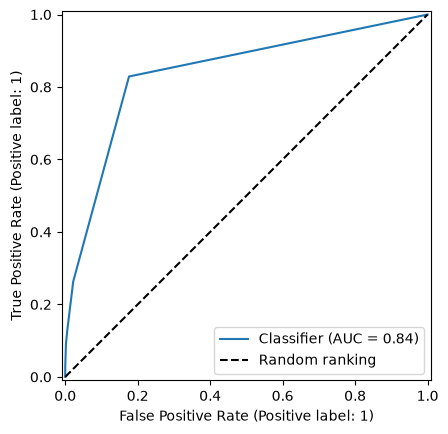

Test AUC: 0.841


In [8]:
RocCurveDisplay.from_predictions(y_test, probability)
plt.plot([0, 1], [0, 1], 'k--', label='Random ranking')
plt.legend()
plt.show()
print('Test AUC:', round(roc_auc_score(y_test, probability), 3))

**Answer:** Yes, the ROC curve lies clearly above the diagonal, and the test AUC is 0.841.

- AUC 0.841 means: for a randomly chosen fatal and a randomly chosen non-fatal accident, the model gives the fatal one the higher probability about 84% of the time (ties count as half).
- A random ranking would give AUC 0.5 (the diagonal); a perfect ranking would give 1.0.
- The curve has only a few corners, because the input takes only a few different values (0, 1, 2, … fully buried).
- AUC summarises the ranking across all thresholds. It is not the percentage of correct class labels: at threshold 0.5, the model ranks well but still finds only 26% of the fatal accidents.

### Jupyter notebook — footer info

Include this information when submitting your notebook.

In [9]:
import platform
from datetime import datetime
print(platform.platform())
print("Python:", platform.python_version())
print("Date:", datetime.now().isoformat(timespec="seconds"))

Linux-6.8.0-1064-azure-x86_64-with-glibc2.41
Python: 3.11.16
Date: 2026-10-02T20:17:09
